# RV plots with fitted RV baseline included

This keeps the RV plotting layout aligned with `alles_plots.ipynb`, but reconstructs the fitted RV baseline explicitly. It works for both `sample_linear` baselines and `sample_offset` baselines.

In [40]:
import os
from plot_images import plot_images
os.environ.setdefault('MPLCONFIGDIR', '/tmp/mpl')
os.environ.setdefault('XDG_CACHE_HOME', '/tmp')
os.environ.setdefault('NUMBA_CACHE_DIR', '/tmp/numba')


import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import allesfitter

sns.set(context='paper', style='ticks', palette='deep', font_scale=1.5, color_codes=True)
sns.set_style({'xtick.direction': 'in', 'ytick.direction': 'in'})
sns.set_context(rc={'lines.markeredgewidth': 1})
plot_images()
DATA_DIR = 'data/2804'
# DATA_DIR = 'data/allesfit_TIC-453_EXT_EXT'

alles = allesfitter.allesclass(DATA_DIR)
posterior_params_median = alles.posterior_params_median
posterior_samples = alles.posterior_params
period = posterior_params_median['b_period']
epoch = posterior_params_median['b_epoch']
dirname = DATA_DIR

Filling the Basement

OrderedDict([('user-given:', ''),
             ('companions_phot', ['b']),
             ('companions_rv', ['b']),
             ('inst_phot', ['TESS', 'NGTS_6', 'NGTS_1', 'sg1']),
             ('inst_rv', ['HARPS', 'CORALIE_1', 'CORALIE_2']),
             ('multiprocess', True),
             ('fast_fit', 'True'),
             ('fast_fit_width', '0.3333333333333333'),
             ('secondary_eclipse', 'False'),
             ('phase_curve', 'False'),
             ('shift_epoch', True),
             ('inst_for_b_epoch',
              ['TESS',
               'NGTS_6',
               'NGTS_1',
               'sg1',
               'HARPS',
               'CORALIE_1',
               'CORALIE_2']),
             ('mcmc_nwalkers', '10'),
             ('mcmc_total_steps', '100'),
             ('mcmc_burn_steps', '50'),
             ('mcmc_thin_by', '1'),
             ('ns_modus', 'dynamic'),
             ('ns_nlive', '500'),
             ('ns_bound', 'single'),
             

In [41]:
def rv_baseline(inst, xx=None, key='rv'):
    time = np.asarray(alles.data[inst]['time'])
    xx = time if xx is None else np.asarray(xx)
    baseline_mode = alles.settings[f'baseline_{key}_{inst}']
    baseline_offset = posterior_params_median[f'baseline_offset_{key}_{inst}']

    if baseline_mode == 'sample_offset':
        return baseline_offset * np.ones_like(xx, dtype=float)

    if baseline_mode == 'sample_linear':
        x0 = time[0]
        x1 = time[-1]
        xx_norm = (xx - x0) / (x1 - x0)
        slope = posterior_params_median[f'baseline_slope_{key}_{inst}']
        return slope * xx_norm + baseline_offset

    raise ValueError(f'Unsupported RV baseline mode for {inst}: {baseline_mode}')


def total_rv_model(inst, xx):
    return alles.get_posterior_median_model(inst=inst, key='rv', xx=xx) + rv_baseline(inst, xx=xx, key='rv')


def get_rv_jitter(inst):
    key = 'jitter_rv_' + inst
    if key in posterior_params_median:
        return posterior_params_median[key]

    ln_key = 'ln_jitter_rv_' + inst
    if ln_key in posterior_params_median:
        return np.exp(posterior_params_median[ln_key])

    return 0.0


def to_phase(P, T_0, t):
    phi = ((t - T_0) / P) % 1
    return phi

K percentiles (m/s): [66.86724495 70.78002483 77.50495944 84.14384958 87.41470013]


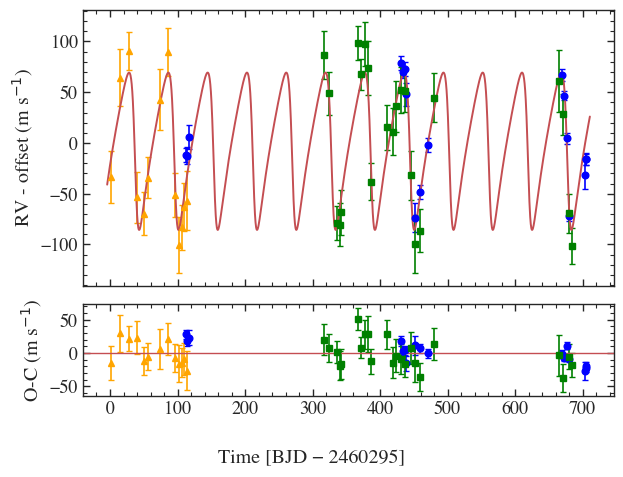

In [42]:
# List of RV instruments
rv_instruments = ['HARPS', 'CORALIE_1', 'CORALIE_2']

# Conversion factor: km/s -> m/s
rv_scale = 1000.0

# ------------------------------------------
# Extract RV datasets
# ------------------------------------------
coralie14_data = alles.data['CORALIE_1']
coralie24_data = alles.data['CORALIE_2']
harps_data     = alles.data['HARPS']

# ------------------------------------------
# Load data and compute RV errors
# ------------------------------------------
for inst in rv_instruments:
    data = alles.data[inst]
    data['rv_err'] = np.sqrt(
        data['white_noise_rv']**2 +
        get_rv_jitter(inst)**2
    )

# Automatically define rv_base_time using min/max of all RV data
all_times = np.hstack([alles.data[inst]['time'] for inst in rv_instruments])

extra_days = 5

rv_base_time = np.linspace(
    all_times.min() - extra_days,
    all_times.max() + extra_days,
    2500
)

# ------------------------------------------
# Compute RV models with fitted baseline included
# ------------------------------------------
rv_offsets_data = {
    inst: posterior_params_median['baseline_offset_rv_' + inst]
    for inst in rv_instruments
}

rv_models = {}
for inst in rv_instruments:
    rv_models[inst] = total_rv_model(inst, rv_base_time) - rv_offsets_data[inst]

model_array = np.array([rv_models[inst] for inst in rv_instruments])
rv_model = np.mean(model_array, axis=0)

# ------------------------------------------
# Calculate K percentiles
# ------------------------------------------
K_samples = posterior_samples['b_K']
K_percentiles = np.percentile(K_samples, [0.00002, 0.3, 50, 99.7, 99.99994])
K_percentiles_ms = K_percentiles * rv_scale
median_K = posterior_params_median['b_K']

print('K percentiles (m/s):', K_percentiles_ms)

rv_mod_3sig_low  = rv_model * K_percentiles[1] / median_K
rv_mod_3sig_high = rv_model * K_percentiles[2] / median_K
rv_mod_5sig_low  = rv_model * K_percentiles[0] / median_K
rv_mod_5sig_high = rv_model * K_percentiles[3] / median_K

# Convert model curves to m/s
rv_model *= rv_scale
rv_mod_3sig_low  *= rv_scale
rv_mod_3sig_high *= rv_scale
rv_mod_5sig_low  *= rv_scale
rv_mod_5sig_high *= rv_scale

# ------------------------------------------
# Helper: evaluate model at data times
# ------------------------------------------
def model_at_times(inst, times):
    return total_rv_model(inst, times) - rv_offsets_data[inst]

# ------------------------------------------
# Prepare plotting times
# ------------------------------------------
t0 = int(all_times.min())

for inst in rv_instruments:
    alles.data[inst]['time_plot'] = alles.data[inst]['time'] - t0

rv_base_time_plot = rv_base_time - t0

# ------------------------------------------
# Plot RVs with instrument-specific offsets
# ------------------------------------------
fig, ax = plt.subplots(2, 1, sharex=True, height_ratios=[3, 1], dpi=100)

markers = {
    'HARPS': 'o',
    'CORALIE_1': '^',
    'CORALIE_2': 's'
}

colors = {
    'HARPS': 'blue',
    'CORALIE_1': 'orange',
    'CORALIE_2': 'green'
}

for inst in rv_instruments:
    d = alles.data[inst]
    offset = rv_offsets_data[inst]
    model_here_true = model_at_times(inst, d['time'])

    rv_data_ms = d['rv'] * rv_scale
    rv_err_ms = d['rv_err'] * rv_scale
    offset_ms = offset * rv_scale
    model_here_true_ms = model_here_true * rv_scale

    ax[0].errorbar(
        d['time_plot'],
        rv_data_ms - offset_ms,
        yerr=rv_err_ms,
        fmt=markers[inst],
        capsize=2,
        color=colors[inst],
        label=inst
    )

    ax[1].errorbar(
        d['time_plot'],
        rv_data_ms - offset_ms - model_here_true_ms,
        yerr=rv_err_ms,
        fmt=markers[inst],
        capsize=2,
        color=colors[inst]
    )

# plot combined model
ax[0].plot(rv_base_time_plot, rv_model, 'r-', lw=1.4, label='Median Model')
ax[1].axhline(0, color='r', lw=1)

fig.supxlabel(f'Time [BJD − {t0}]')
ax[0].set_ylabel('RV - offset (m s$^{-1}$)')
ax[1].set_ylabel('O-C (m s$^{-1}$)')

# ax[0].legend()
fig.tight_layout()
fig.savefig(dirname + '/TIC_RV_TIME_with_baseline.pdf', bbox_inches='tight')
plt.show()

HARPS offset (baseline offset) = 41992.568 m/s
CORALIE_1 offset (baseline offset) = 42110.270 m/s
CORALIE_2 offset (baseline offset) = 42088.547 m/s


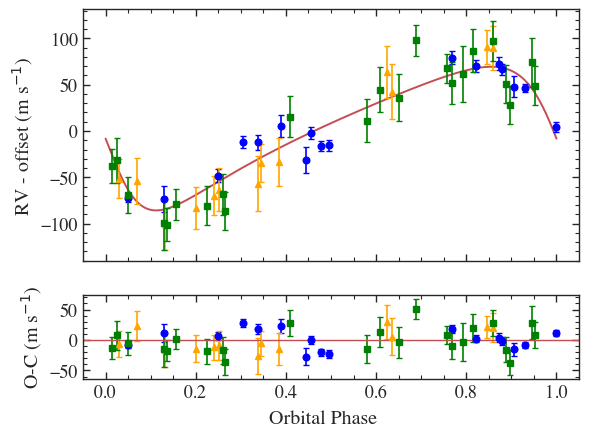

In [43]:
# Conversion factor: km/s -> m/s
rv_scale = 1000.0

# Create figure with 2 subplots
fig, ax = plt.subplots(2, 1, sharex=True, height_ratios=[3, 1], dpi=100)

# Compute RV offsets per instrument
rv_offsets_data = {}
for inst in rv_instruments:
    rv_offsets_data[inst] = posterior_params_median['baseline_offset_rv_' + inst]
    print(f"{inst} offset (baseline offset) = {rv_offsets_data[inst] * rv_scale:.3f} m/s")

# Phase-folded time grid for median model
phase_grid = np.linspace(0, 1, 2000)
t_model = epoch + phase_grid * period

# Model in m/s
rv_model = alles.get_posterior_median_model(inst='CORALIE_1', key='rv', xx=t_model) * rv_scale

# Median model
ax[0].plot(phase_grid, rv_model, 'r-', lw=1.4)

# Plot each instrument
for inst in rv_instruments:
    d = alles.data[inst]
    ph = to_phase(period, epoch, d['time'])
    model_here = alles.get_posterior_median_model(inst=inst, key='rv', xx=d['time']) * rv_scale
    baseline_here = rv_baseline(inst, d['time']) * rv_scale

    rv_data_ms = d['rv'] * rv_scale
    rv_err_ms = d['rv_err'] * rv_scale

    ax[0].errorbar(
        ph,
        rv_data_ms - baseline_here,
        yerr=rv_err_ms,
        fmt=markers[inst],
        capsize=2,
        color=colors[inst],
        label=inst
    )

    ax[1].errorbar(
        ph,
        rv_data_ms - baseline_here - model_here,
        yerr=rv_err_ms,
        fmt=markers[inst],
        capsize=2,
        color=colors[inst]
    )

ax[1].axhline(0, color='r', lw=1)

# Labels
ax[0].set_ylabel('RV - offset (m s$^{-1}$)')
ax[1].set_ylabel('O-C (m s$^{-1}$)')
fig.supxlabel('Orbital Phase')
# ax[0].legend(loc='best')

fig.savefig(dirname + '/TIC_RV_PHASE_with_baseline.pdf', bbox_inches='tight')
plt.show()

## How the drift is measured

This diagnostic does **not** read a drift parameter from the fit, because the `data/2804` rerun uses `sample_offset` for the RV baselines and therefore does not include a fitted linear RV trend. Instead, the drift is estimated **after the fit** from the RV residuals.

The steps are:

1. For each RV instrument, compute the residuals after subtracting the fitted Keplerian model and the fitted instrument offset:

$$\mathrm{RV}_{\mathrm{resid}}(t) = \mathrm{RV}_{\mathrm{data}}(t) - \gamma_{\mathrm{inst}} - \mathrm{RV}_{\mathrm{planet}}(t).$$

2. Convert the residuals and their uncertainties to m/s.

3. Fit a weighted straight line to the residuals as a function of time, using weights $1/\sigma^2$.

4. Do this twice: once for all RV instruments combined, and once for HARPS only.

The reported slope is therefore a **post-fit empirical drift estimate** in m/s/day. It is useful as a diagnostic for whether a missing long-term RV drift is present, but it is not yet a physical drift parameter sampled by the global `allesfitter` model.


Combined residual slope: -0.043 +/- 0.007 m/s/day
HARPS residual slope: -0.057 +/- 0.008 m/s/day


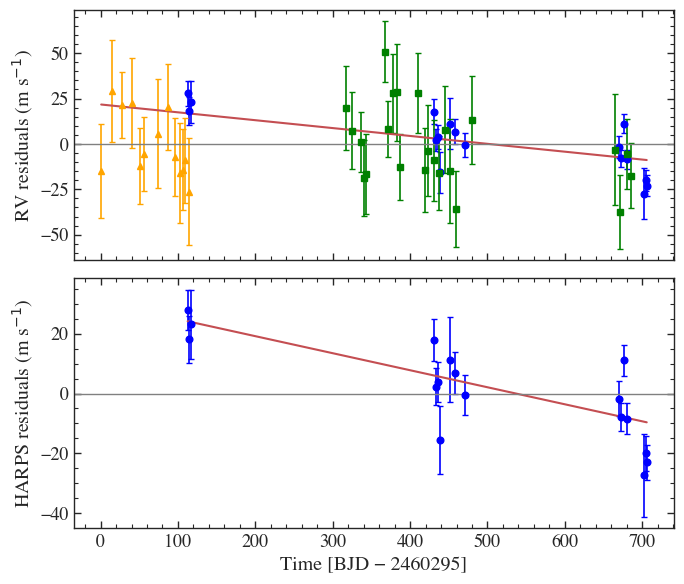

In [45]:
# Measure an empirical residual drift after the fit.
# This uses RV residuals = data - instrument offset - Keplerian model,
# then fits a weighted straight line in time.

def weighted_line_fit(x, y, yerr):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    yerr = np.asarray(yerr, dtype=float)

    tref = np.mean(x)
    x_fit = x - tref
    w = 1.0 / yerr**2

    A = np.column_stack([x_fit, np.ones_like(x_fit)])
    ATA = A.T @ (w[:, None] * A)
    ATy = A.T @ (w * y)
    coeff = np.linalg.solve(ATA, ATy)
    cov = np.linalg.inv(ATA)

    slope = coeff[0]
    intercept = coeff[1]
    slope_err = np.sqrt(cov[0, 0])
    intercept_err = np.sqrt(cov[1, 1])

    return {
        'slope': slope,
        'intercept': intercept,
        'slope_err': slope_err,
        'intercept_err': intercept_err,
        'tref': tref,
    }


residual_data = {}
for inst in rv_instruments:
    d = alles.data[inst]
    offset = posterior_params_median['baseline_offset_rv_' + inst]
    model_here = alles.get_posterior_median_model(inst=inst, key='rv', xx=d['time'])

    time_plot = d['time'] - t0
    rv_resid_ms = d['rv'] * rv_scale - offset * rv_scale - model_here * rv_scale
    rv_err_ms = d['rv_err'] * rv_scale

    residual_data[inst] = {
        'time_plot': time_plot,
        'resid': rv_resid_ms,
        'err': rv_err_ms,
    }

all_time = np.concatenate([residual_data[inst]['time_plot'] for inst in rv_instruments])
all_resid = np.concatenate([residual_data[inst]['resid'] for inst in rv_instruments])
all_err = np.concatenate([residual_data[inst]['err'] for inst in rv_instruments])

combined_fit = weighted_line_fit(all_time, all_resid, all_err)
harps_fit = weighted_line_fit(
    residual_data['HARPS']['time_plot'],
    residual_data['HARPS']['resid'],
    residual_data['HARPS']['err'],
)

print(f"Combined residual slope: {combined_fit['slope']:.3f} +/- {combined_fit['slope_err']:.3f} m/s/day")
print(f"HARPS residual slope: {harps_fit['slope']:.3f} +/- {harps_fit['slope_err']:.3f} m/s/day")

time_grid_all = np.linspace(all_time.min(), all_time.max(), 1000)
time_grid_harps = np.linspace(
    residual_data['HARPS']['time_plot'].min(),
    residual_data['HARPS']['time_plot'].max(),
    1000,
)

fig, ax = plt.subplots(2, 1, sharex=True, figsize=(7, 6))

for inst in rv_instruments:
    ax[0].errorbar(
        residual_data[inst]['time_plot'],
        residual_data[inst]['resid'],
        yerr=residual_data[inst]['err'],
        fmt=markers[inst],
        capsize=2,
        color=colors[inst],
        label=inst,
    )

ax[0].plot(
    time_grid_all,
    combined_fit['slope'] * (time_grid_all - combined_fit['tref']) + combined_fit['intercept'],
    'r-',
    lw=1.5,
    label='Combined trend fit',
)
ax[0].axhline(0, color='0.5', lw=1)
ax[0].set_ylabel('RV residuals (m s$^{-1}$)')
# ax[0].legend(loc='best')

ax[1].errorbar(
    residual_data['HARPS']['time_plot'],
    residual_data['HARPS']['resid'],
    yerr=residual_data['HARPS']['err'],
    fmt=markers['HARPS'],
    capsize=2,
    color=colors['HARPS'],
)
ax[1].plot(
    time_grid_harps,
    harps_fit['slope'] * (time_grid_harps - harps_fit['tref']) + harps_fit['intercept'],
    'r-',
    lw=1.5,
)
ax[1].axhline(0, color='0.5', lw=1)
ax[1].set_ylabel('HARPS residuals (m s$^{-1}$)')
ax[1].set_xlabel(f'Time [BJD − {t0}]')

fig.tight_layout()
fig.savefig(dirname + '/TIC_RV_residual_trends.pdf', bbox_inches='tight')
plt.show()
